In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os


DATASET_PATH = "/content/drive/MyDrive/Final_Navarasa_Dataset"

# List emotion folders
classes = sorted([
    folder for folder in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, folder))
])

print("Number of classes:", len(classes))
print("Emotion classes:")
for cls in classes:
    print("-", cls)


Number of classes: 9
Emotion classes:
- Adbutha
- Bhayanaka
- Bibhatsa
- Hasya
- Karuna
- Raudra
- Shantha
- Shringara
- Veera


Count Images Per Class

In [3]:
image_count_per_class = {}
total_images = 0

for cls in classes:
    class_path = os.path.join(DATASET_PATH, cls)
    images = [
        img for img in os.listdir(class_path)
        if img.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]
    image_count_per_class[cls] = len(images)
    total_images += len(images)

print("\nImage count per class:")
for cls, count in image_count_per_class.items():
    print(f"{cls}: {count}")

print("\nTotal images in dataset:", total_images)



Image count per class:
Adbutha: 1239
Bhayanaka: 922
Bibhatsa: 2985
Hasya: 5288
Karuna: 739
Raudra: 899
Shantha: 1201
Shringara: 1083
Veera: 808

Total images in dataset: 15164


Dataset Summary

In [4]:
print("\n--- DATASET SUMMARY ---")
print(f"Dataset Path: {DATASET_PATH}")
print(f"Total Classes: {len(classes)}")
print(f"Total Images: {total_images}")
print("Images are organized in folder-wise class format.")



--- DATASET SUMMARY ---
Dataset Path: /content/drive/MyDrive/Final_Navarasa_Dataset
Total Classes: 9
Total Images: 15164
Images are organized in folder-wise class format.


## **Class Distribution**
### Images per Emotion

In [5]:
import matplotlib.pyplot as plt


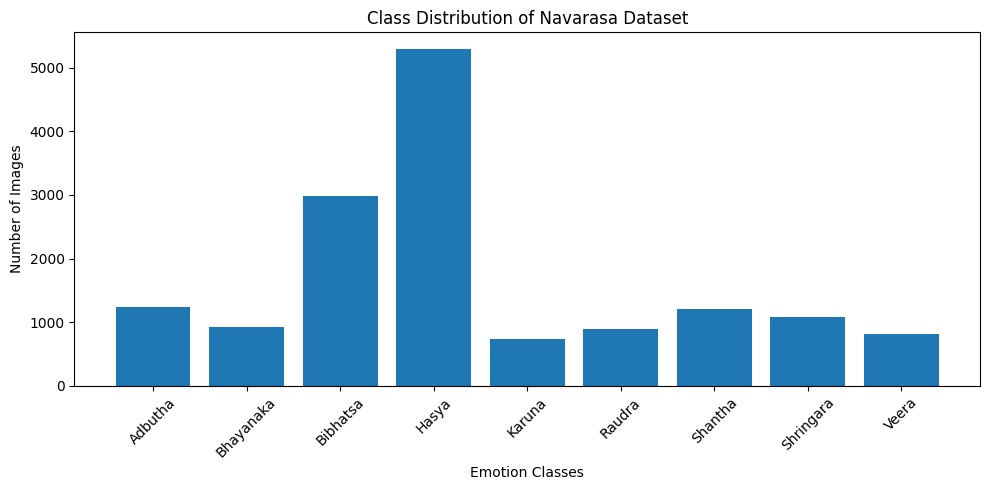

In [6]:
classes = list(image_count_per_class.keys())
counts = list(image_count_per_class.values())

plt.figure(figsize=(10, 5))
plt.bar(classes, counts)
plt.xlabel("Emotion Classes")
plt.ylabel("Number of Images")
plt.title("Class Distribution of Navarasa Dataset")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Percentage Distribution

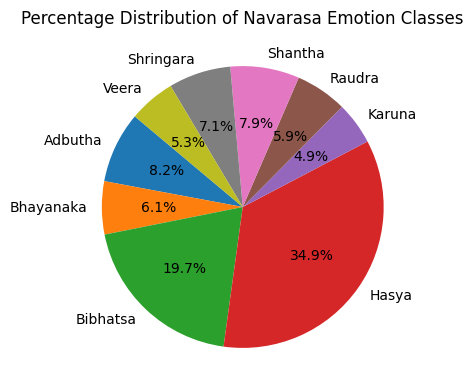

In [7]:
plt.figure(figsize=(4, 4))
plt.pie(
    counts,
    labels=classes,
    autopct='%1.1f%%',
    startangle=140
)
plt.title("Percentage Distribution of Navarasa Emotion Classes\n")
plt.axis('equal')
plt.show()



### Imbalance ratio

In [8]:
max_count = max(counts)
min_count = min(counts)

imbalance_ratio = max_count / min_count

print("Maximum images in a class:", max_count)
print("Minimum images in a class:", min_count)
print("Imbalance ratio (max/min):", round(imbalance_ratio, 2))


Maximum images in a class: 5288
Minimum images in a class: 739
Imbalance ratio (max/min): 7.16


### Sample Images per Emotion

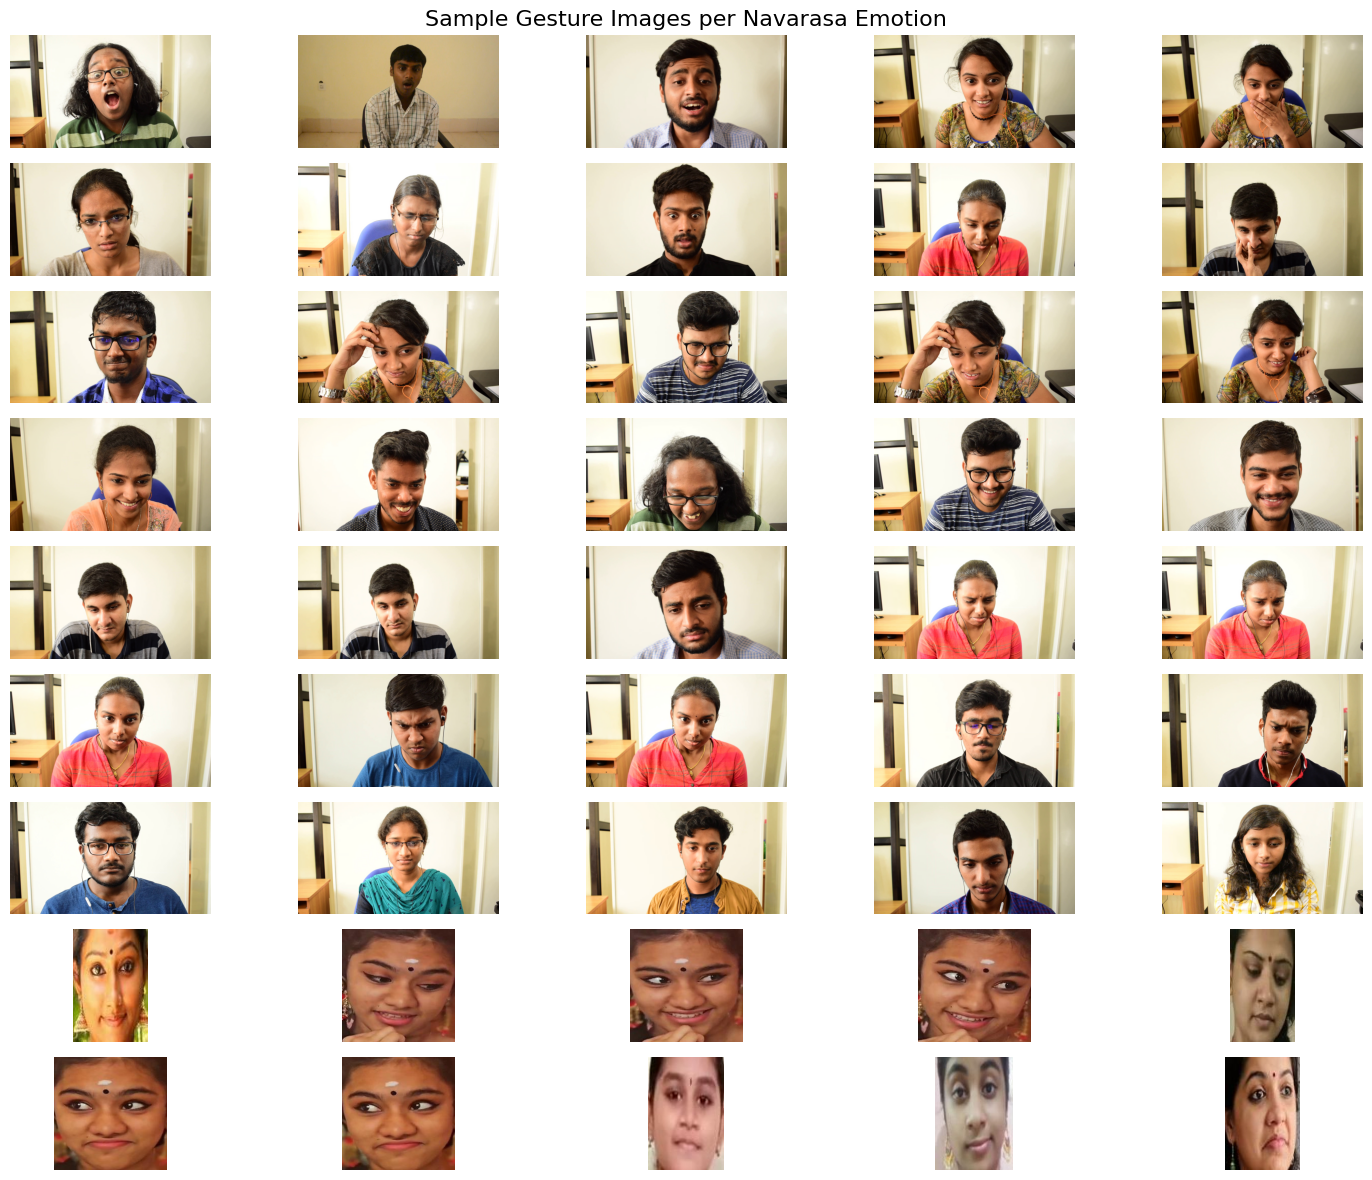

In [12]:
SAMPLES_PER_CLASS = 5

plt.figure(figsize=(15, 12))

plot_index = 1

for cls in classes:
    class_path = os.path.join(DATASET_PATH, cls)

    images = [
        img for img in os.listdir(class_path)
        if img.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    sampled_images = random.sample(images, min(SAMPLES_PER_CLASS, len(images)))

    for img_name in sampled_images:
        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)

        plt.subplot(len(classes), SAMPLES_PER_CLASS, plot_index)
        plt.imshow(img)
        plt.axis('off')

        if plot_index % SAMPLES_PER_CLASS == 1:
            plt.ylabel(cls, fontsize=12)

        plot_index += 1

plt.suptitle("Sample Gesture Images per Navarasa Emotion", fontsize=16)
plt.tight_layout()
plt.show()


###  Aspect Ratio Analysis

In [13]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt


In [14]:
IMAGES_PER_CLASS = 10


In [15]:
image_widths = []
image_heights = []
aspect_ratios = []

for cls in classes:
    class_path = os.path.join(DATASET_PATH, cls)

    images = [
        img for img in os.listdir(class_path)
        if img.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    sampled_images = random.sample(
        images,
        min(IMAGES_PER_CLASS, len(images))
    )

    for img_name in sampled_images:
        img_path = os.path.join(class_path, img_name)

        try:
            with Image.open(img_path) as img:
                w, h = img.size
                image_widths.append(w)
                image_heights.append(h)
                aspect_ratios.append(w / h)
        except:
            continue


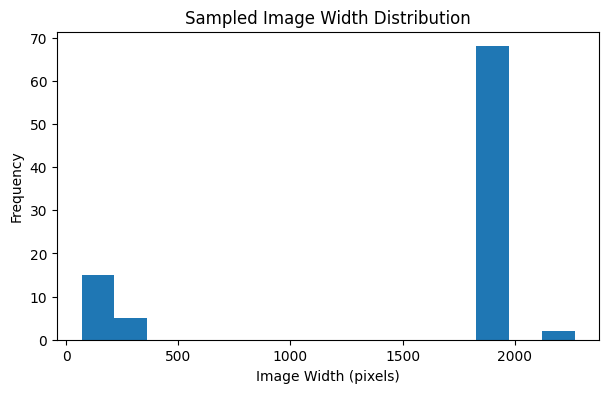

In [16]:
plt.figure(figsize=(7, 4))
plt.hist(image_widths, bins=15)
plt.xlabel("Image Width (pixels)")
plt.ylabel("Frequency")
plt.title("Sampled Image Width Distribution")
plt.show()


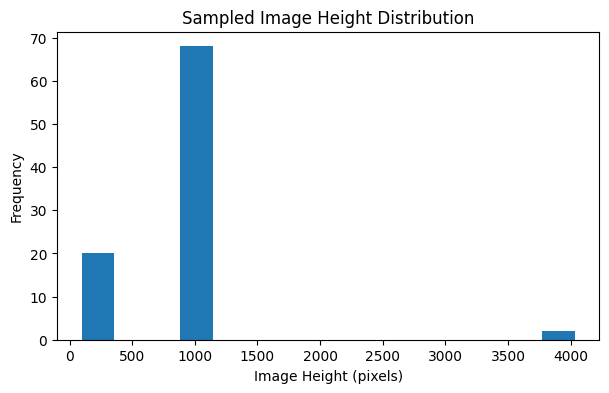

In [17]:
plt.figure(figsize=(7, 4))
plt.hist(image_heights, bins=15)
plt.xlabel("Image Height (pixels)")
plt.ylabel("Frequency")
plt.title("Sampled Image Height Distribution")
plt.show()


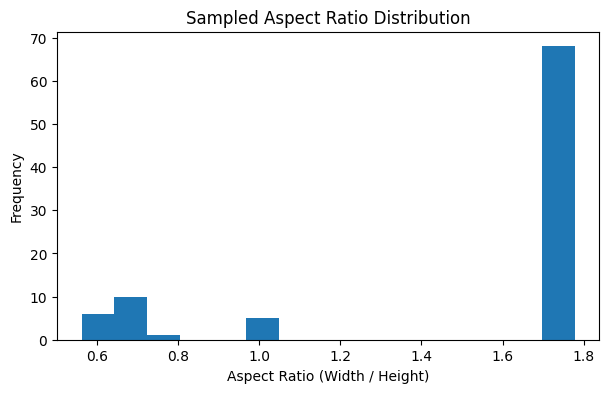

In [18]:
plt.figure(figsize=(7, 4))
plt.hist(aspect_ratios, bins=15)
plt.xlabel("Aspect Ratio (Width / Height)")
plt.ylabel("Frequency")
plt.title("Sampled Aspect Ratio Distribution")
plt.show()


In [19]:
print("Total images analyzed:", len(image_widths))

print("\nWidth Statistics:")
print(" Min:", min(image_widths))
print(" Max:", max(image_widths))
print(" Avg:", int(sum(image_widths) / len(image_widths)))

print("\nHeight Statistics:")
print(" Min:", min(image_heights))
print(" Max:", max(image_heights))
print(" Avg:", int(sum(image_heights) / len(image_heights)))


Total images analyzed: 90

Width Statistics:
 Min: 69
 Max: 2268
 Avg: 1528

Height Statistics:
 Min: 96
 Max: 4032
 Avg: 940


### Data Quality & Cleaning Analysis

In [ ]:
corrupted_images = []

for cls in classes:
    class_path = os.path.join(DATASET_PATH, cls)

    for img_name in os.listdir(class_path):
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            img_path = os.path.join(class_path, img_name)

            try:
                with Image.open(img_path) as img:
                    img.verify()
            except:
                corrupted_images.append(img_path)


In [ ]:
print("Total corrupted images found:", len(corrupted_images))

if corrupted_images:
    print("\nSample corrupted images:")
    for img in corrupted_images[:5]:
        print(img)
